In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv(dotenv_path='F:\\agentic_ai\\AgenticAIWorkspace\\.env')
import os


In [4]:
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
model = ChatOpenAI(model_name="gpt-3.5-turbo", temperature=0)


In [5]:
class BlogState(TypedDict):
    topic:str
    outline:str
    content:str

In [ ]:
def create_outline(state:BlogState) -> BlogState:
    prompt = f"Create a detailed outline for a blog post about the topic: {state['topic']}"
    outline = model.invoke(prompt).content
    state['outline'] = outline
    return state

def write_content(state:BlogState) -> BlogState:
    
    prompt = f"Write a detailed blog post based on the following outline and topic: \n Topic: {state['topic']} \n Outline: {state['outline']}"
    content = model.invoke(prompt).content
    state['content'] = content
    return state

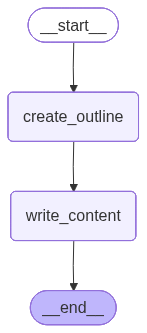

In [11]:
graph = StateGraph(BlogState)

# add nodes
graph.add_node('create_outline',create_outline)
graph.add_node('write_content',write_content)

#add edges
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','write_content')
graph.add_edge('write_content',END)

workflow = graph.compile()
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))


In [13]:
# Execute the workflw
initial_state = {'topic': "The Future of Artificial Intelligence in everyday life"}
final_state = workflow.invoke(initial_state)
print(final_state['content'])

Artificial intelligence (AI) has become an integral part of our daily lives, from the smart devices we use at home to the virtual assistants that help us navigate our busy schedules. As AI continues to advance at a rapid pace, the future holds great potential for transforming various aspects of daily life in ways we may not have imagined before. In this blog post, we will explore the current applications of AI in everyday life, potential future applications, ethical and social implications, challenges and limitations, and the importance of responsible development and deployment of AI.

Current Applications of AI in Everyday Life

Smart home devices have become increasingly popular, allowing us to control our lights, thermostats, and security systems with just a few taps on our smartphones. Virtual assistants like Siri, Alexa, and Google Assistant have become our go-to helpers for setting reminders, answering questions, and even ordering groceries. Personalized recommendations on stream

In [14]:
print(final_state['outline'])

I. Introduction
    A. Brief overview of artificial intelligence (AI)
    B. Importance of AI in everyday life
    C. Thesis statement: The future of AI holds great potential for transforming various aspects of daily life

II. Current Applications of AI in Everyday Life
    A. Smart home devices
    B. Virtual assistants
    C. Personalized recommendations
    D. Autonomous vehicles
    E. Healthcare diagnostics

III. Potential Future Applications of AI in Everyday Life
    A. Enhanced personalization in shopping and entertainment
    B. Improved healthcare services
    C. Increased efficiency in transportation and logistics
    D. Advancements in education and learning
    E. Impact on job market and workforce

IV. Ethical and Social Implications of AI in Everyday Life
    A. Privacy concerns
    B. Bias and discrimination
    C. Job displacement
    D. Regulation and oversight

V. Challenges and Limitations of AI in Everyday Life
    A. Technical limitations
    B. Lack of transparen